# Introduction

The purpose of this exploratory analysis is to gain a better understanding of the dataset before applying deep learning techniques. The analysis examines the structure and quality of the metadata, the distribution of the target variable, patient-level information and characteristics of the available images. Particular attention is given to missing values, duplicate observations and other factors that may influence the performance and reliability of a predictive model.

### Task definition

This is a binary image classification problem: given a dermoscopic image of a skin lesion, the goal is to predict whether it is **benign** or **malignant** (melanoma). Each observation also includes patient metadata (`sex`, `age_approx`, `anatom_site_general_challenge`), which may provide additional predictive signal alongside the image itself.

In [262]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from scipy.stats import skew
from PIL import Image
import os

### Loading and exploring the data

In [263]:
# Paths
TRAIN_PATH = '../data/raw/train.csv'
TEST_PATH = '../data/raw/test.csv'
TRAIN_IMG_DIR = '../data/raw/jpeg/train'
TEST_IMG_DIR = '../data/raw/jpeg/test'

try:
    # Loading the training and test datasets
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)

    print("Datasets loaded successfully")
    print(f"Train dataset -> {train_df.shape[0]} rows, {train_df.shape[1]} columns")
    print(f"Test dataset  -> {test_df.shape[0]} rows, {test_df.shape[1]} columns")

except FileNotFoundError as e:
    print(f"Error: Could not find the dataset file: {e.filename}")

except Exception as e:
    print(f"An unexpected error occurred: {e}")

Datasets loaded successfully
Train dataset -> 33126 rows, 8 columns
Test dataset  -> 10982 rows, 5 columns


In [264]:
train_df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


In [265]:
train_df.describe()

,age_approx,target
count,33058.000000,33126.000000
mean,48.870016,0.017630
std,14.380360,0.131603
min,0.000000,0.000000
25%,40.000000,0.000000
50%,50.000000,0.000000
75%,60.000000,0.000000
max,90.000000,1.000000


In [266]:
test_df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge
0,ISIC_0052060,IP_3579794,male,70.0,NaN
1,ISIC_0052349,IP_7782715,male,40.0,lower extremity
2,ISIC_0058510,IP_7960270,female,55.0,torso
3,ISIC_0073313,IP_6375035,female,50.0,torso
4,ISIC_0073502,IP_0589375,female,45.0,lower extremity


In [267]:
test_df.describe()

,age_approx
count,10982.000000
mean,49.525587
std,14.370589
min,10.000000
25%,40.000000
50%,50.000000
75%,60.000000
max,90.000000


In [268]:
class Style:
    GREEN = '\033[32m'
    BOLD = '\033[1m'
    END = '\033[0m'

def print_header(title, width=90):
    border = '*' * width
    title = f"*{title.center(width - 2)}*"
    print(f"{Style.GREEN}{Style.BOLD}{border}")
    print(title)
    print(f"{border}{Style.END}")

print_header("TRAIN DATASET INFO", 60)
print(train_df.info())

print_header("TEST DATASET INFO", 60)
print(test_df.info())

************************************************************
*                    TRAIN DATASET INFO                    *
************************************************************
<class 'pandas.DataFrame'>
RangeIndex: 33126 entries, 0 to 33125
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_name                     33126 non-null  str    
 1   patient_id                     33126 non-null  str    
 2   sex                            33061 non-null  str    
 3   age_approx                     33058 non-null  float64
 4   anatom_site_general_challenge  32599 non-null  str    
 5   diagnosis                      33126 non-null  str    
 6   benign_malignant               33126 non-null  str    
 7   target                         33126 non-null  int64  
dtypes: float64(1), int64(1), str(6)
memory usage: 2.0 MB
None
*********************************************************

Several columns (`sex`, `anatom_site_general_challenge`, `diagnosis`, `benign_malignant`) are categorical and need to be encoded into a numeric format before being used in a model. `patient_id` is also categorical, but functions as an identifier rather than a predictive feature. It may be used to define patient-level train/validation splits. `image_name` is also an identifier rather than a feature, but it is required to load the corresponding image file for each observation.

### Missing values

In [269]:
print_header("TRAIN DATASET MISSING VALUES", 60)
print(train_df.isna().sum())

print()

print_header("TEST DATASET MISSING VALUES", 60)
print(test_df.isna().sum())

************************************************************
*               TRAIN DATASET MISSING VALUES               *
************************************************************
image_name                         0
patient_id                         0
sex                               65
age_approx                        68
anatom_site_general_challenge    527
diagnosis                          0
benign_malignant                   0
target                             0
dtype: int64

************************************************************
*               TEST DATASET MISSING VALUES                *
************************************************************
image_name                         0
patient_id                         0
sex                                0
age_approx                         0
anatom_site_general_challenge    351
dtype: int64


The test set's `anatom_site_general_challenge` contains the same 6 categories as the train set (verified separately).

In [270]:
def unique_and_missing_values(cols):
    for col in cols:
        unique_qnt = train_df[col].nunique()
        missing_qnt = train_df[col].isna().sum()
        counts = train_df[col].value_counts(dropna=True)

        max_len = max(len(str(v)) for v in counts.index)
        
        print(f'{Style.GREEN}{Style.BOLD}{col}{Style.END}')
        print(f'Number of distinct values: {unique_qnt}')
        print(f'Missing quantity: {missing_qnt}')
        print()
        for v, c in counts.items():
            print(f'-> {str(v):<{max_len}} | {c}')
        print()

contains_missing_value_train = ['sex', 'age_approx', 'anatom_site_general_challenge']
contains_missing_value_test = ['anatom_site_general_challenge']

unique_and_missing_values(contains_missing_value_train)

sex
Number of distinct values: 2
Missing quantity: 65

-> male   | 17080
-> female | 15981

age_approx
Number of distinct values: 18
Missing quantity: 68

-> 45.0 | 4466
-> 50.0 | 4270
-> 55.0 | 3824
-> 40.0 | 3576
-> 60.0 | 3240
-> 35.0 | 2850
-> 65.0 | 2527
-> 30.0 | 2358
-> 70.0 | 1968
-> 25.0 | 1544
-> 75.0 | 981
-> 20.0 | 655
-> 80.0 | 419
-> 85.0 | 149
-> 15.0 | 132
-> 90.0 | 80
-> 10.0 | 17
-> 0.0  | 2

anatom_site_general_challenge
Number of distinct values: 6
Missing quantity: 527

-> torso           | 16845
-> lower extremity | 8417
-> upper extremity | 4983
-> head/neck       | 1855
-> palms/soles     | 375
-> oral/genital    | 124



The test set's `anatom_site_general_challenge` contains the same 6 categories as the train set.

The matrix below visualizes the pattern of missingness across both datasets. Useful for spotting whether missingness is random or clustered.

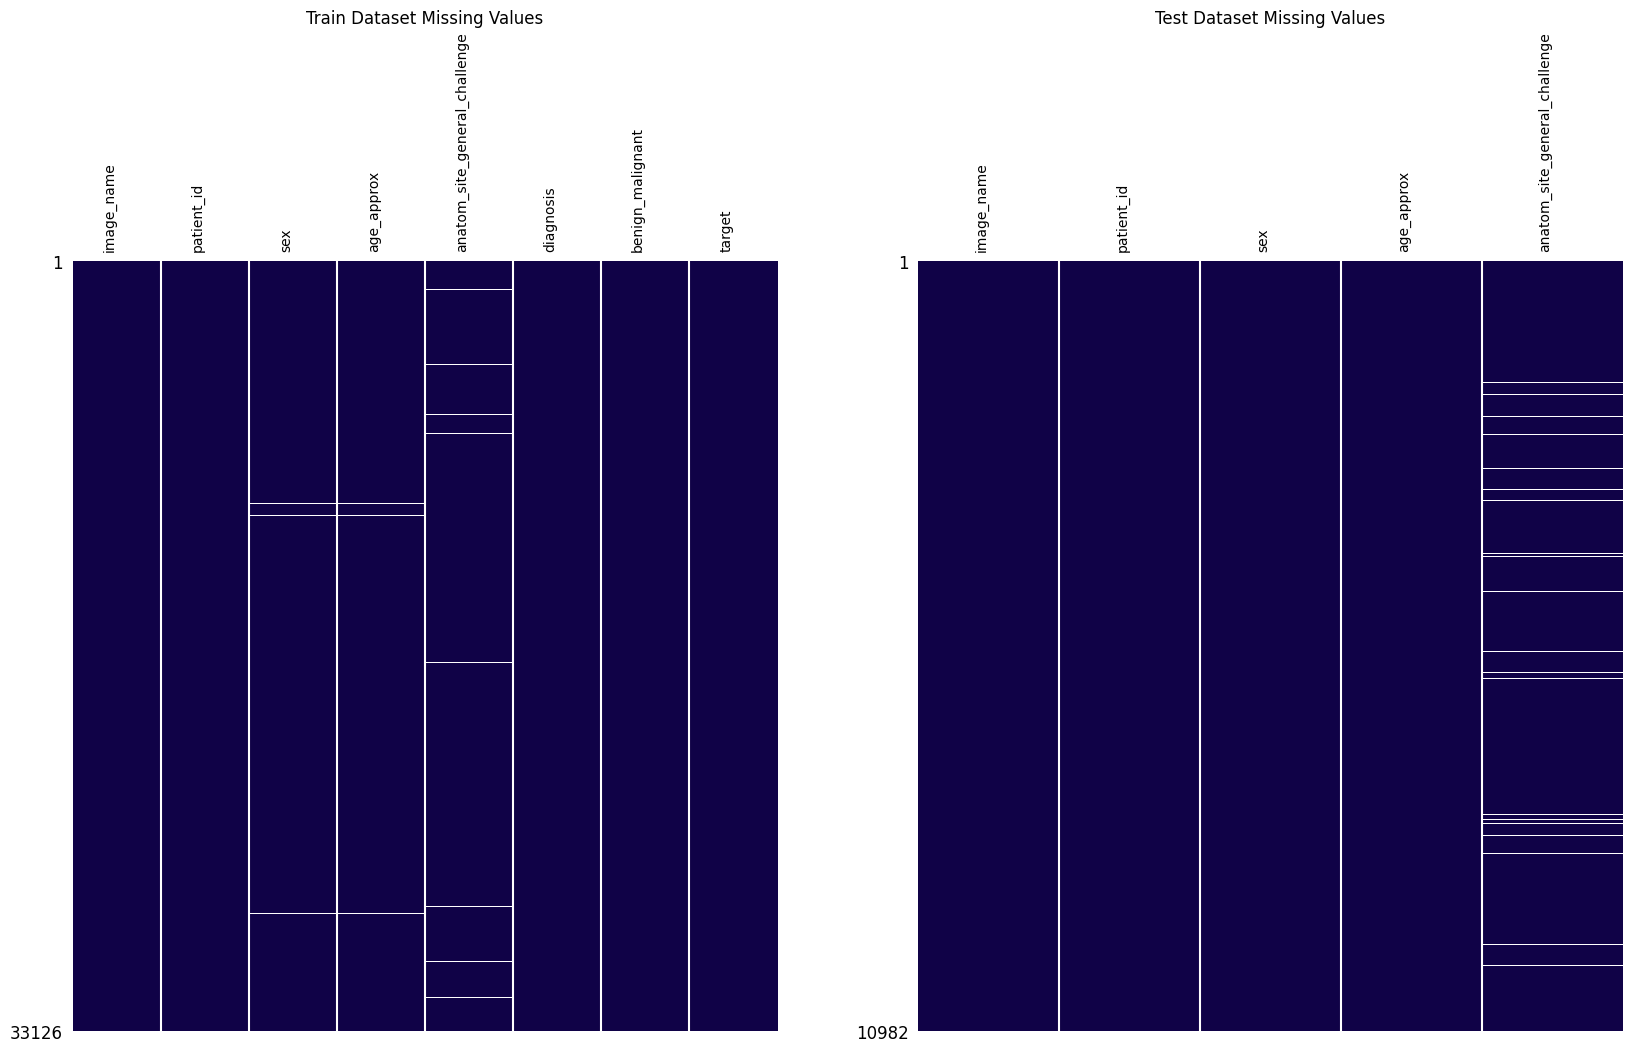

In [271]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

msno.matrix(train_df, color=(16/255, 2/255, 71/255), ax=axes[0], fontsize=10, sparkline=False)
axes[0].set_title("Train Dataset Missing Values", fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90, ha='right')

msno.matrix(test_df, color=(16/255, 2/255, 71/255), ax=axes[1], fontsize=10, sparkline=False)
axes[1].set_title("Test Dataset Missing Values", fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, ha='right')

plt.show()

### Checking whether missingness is correlated across features
---
The missing-value matrix suggests that rows missing `sex` may also be missing `age_approx`. To confirm this pattern quantitatively we examine how often these two fields are missing together versus independently.

In [272]:
missing_combo = train_df[['sex', 'age_approx']].isna()

combo_counts = missing_combo.value_counts()
combo_counts

sex    age_approx
False  False         33058
True   True             65
False  True              3
Name: count, dtype: int64

The results confirm that missingness in `sex` and `age_approx` is not independent. The majority of missing values in both columns occur on the same rows, suggesting a shared underlying cause.

### Target Distribution
---
Before proceeding further, it is important to examine the balance of the target variable, since class imbalance can significantly affect model training and evaluation. The pie chart below shows the proportion of benign versus malignant cases in the training set.

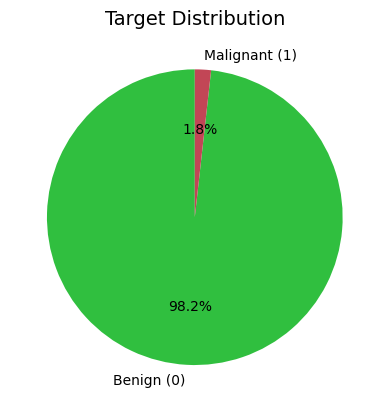

In [273]:
target_counts = train_df['target'].value_counts().sort_index()

plt.pie(target_counts, labels=['Benign (0)', 'Malignant (1)'], autopct='%1.1f%%', startangle=90, colors=['#30bf3f', '#c24656'])
plt.title('Target Distribution', fontsize=14)
plt.show()

#### Conclusion
The dataset is heavily imbalanced, with malignant cases representing only a small fraction of the total samples. This imbalance must be accounted for during model training (e.g. through class weighting, augmentation or resampling) to prevent the model from simply predicting the majority class.

### Unique values count
---
Before proceeding further, we check the number of unique values in each column to better understand the structure of the dataset.

In [274]:
cols = ['image_name', 'patient_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'benign_malignant', 'target']

max_len = max(len(col) for col in cols)

for col in cols:
    print(f'{col:<{max_len}}  {train_df[col].nunique()}')

image_name                     33126
patient_id                     2056
sex                            2
age_approx                     18
anatom_site_general_challenge  6
diagnosis                      9
benign_malignant               2
target                         2


### Checking for duplicates

In [275]:
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())

0
0


No exact duplicate rows were found. However, the dataset contains 33,126 images belonging to only 2,056 unique patients, confirming that many patients have multiple entries and that the data is not independent at the row level. We next check the quantity of entries per `patient_id`.

In [276]:
train_df["patient_id"].value_counts().loc[lambda x: x > 1]

patient_id
IP_7279968    115
IP_4479736    115
IP_4938382    115
IP_4382720    115
IP_0656529    114
             ... 
IP_1545708      3
IP_7548727      3
IP_6349217      3
IP_3645134      3
IP_8335299      2
Name: count, Length: 2056, dtype: int64

#### Conclusion
A large number of patients have multiple images in the dataset. It may have direct implications for how the data should be split for training and validation.

### Possible data leakage check
---
A single patient can have many images, thus randomly splitting the dataset by row risks data leakage. The same patient's lesion could appear in both the training and validation sets. Before addressing this in preprocessing, we visually inspect a sample patient's images to understand how similar or different their multiple entries are.

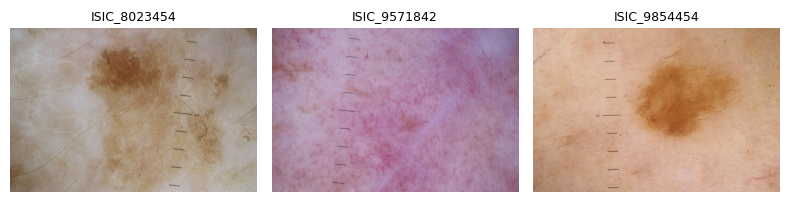

In [277]:
patient_id = 'IP_6349217'
patient_images = train_df[train_df['patient_id'] == patient_id]['image_name'].tolist()

fig, axes = plt.subplots(1, len(patient_images), figsize=(8, 4))

for ax, img_name in zip(axes, patient_images):
    img_path = os.path.join(TRAIN_IMG_DIR, f'{img_name}.jpg')
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

#### Conclusion
The images for this patient show different lesions or angles, confirming that multiple entries per patient are not merely duplicate photos but distinct observations. As a patient's images are related but not identical, a naive row-level split could still leak information about a specific patient's skin characteristics between training and validation sets.

### Age outlier: is there really an infant (0 age)?

In [278]:
Q1 = train_df['age_approx'].quantile(0.25)
Q3 = train_df['age_approx'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_df[(train_df['age_approx'] < lower_bound) | (train_df['age_approx'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
outliers[['patient_id', 'age_approx']]

Number of outliers: 2


,patient_id,age_approx
9647,IP_1300691,0.0
22645,IP_1300691,0.0


In [279]:
zero_age_rows = train_df[train_df['age_approx'] == 0]
zero_age_patients = zero_age_rows['patient_id'].unique()

for p_id in zero_age_patients:
    display(train_df[train_df['patient_id'] == p_id])

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
3019,ISIC_1005683,IP_1300691,male,10.0,torso,unknown,benign,0
9647,ISIC_2988939,IP_1300691,male,0.0,torso,unknown,benign,0
22645,ISIC_6872638,IP_1300691,male,0.0,torso,unknown,benign,0


#### Conclusion
Only 2 rows in the dataset have `age_approx = 0`, and both belong to the same patient, who also has a separate entry recording their age as 10. This is likely explained by one of two possibilities: either `age_approx = 0` was a data entry error or the dataset spans multiple examinations over several years.

### Sample count vs. malignant rate by anatomical site
---
The two charts below are shown side by side to allow direct comparison: the left chart shows how many samples exist for each anatomical site, while the right chart shows the malignant rate for each site. Viewing them together is important, because a site with very few samples can show a misleadingly high or low rate. Each site uses a consistent color across both charts for easier comparison.

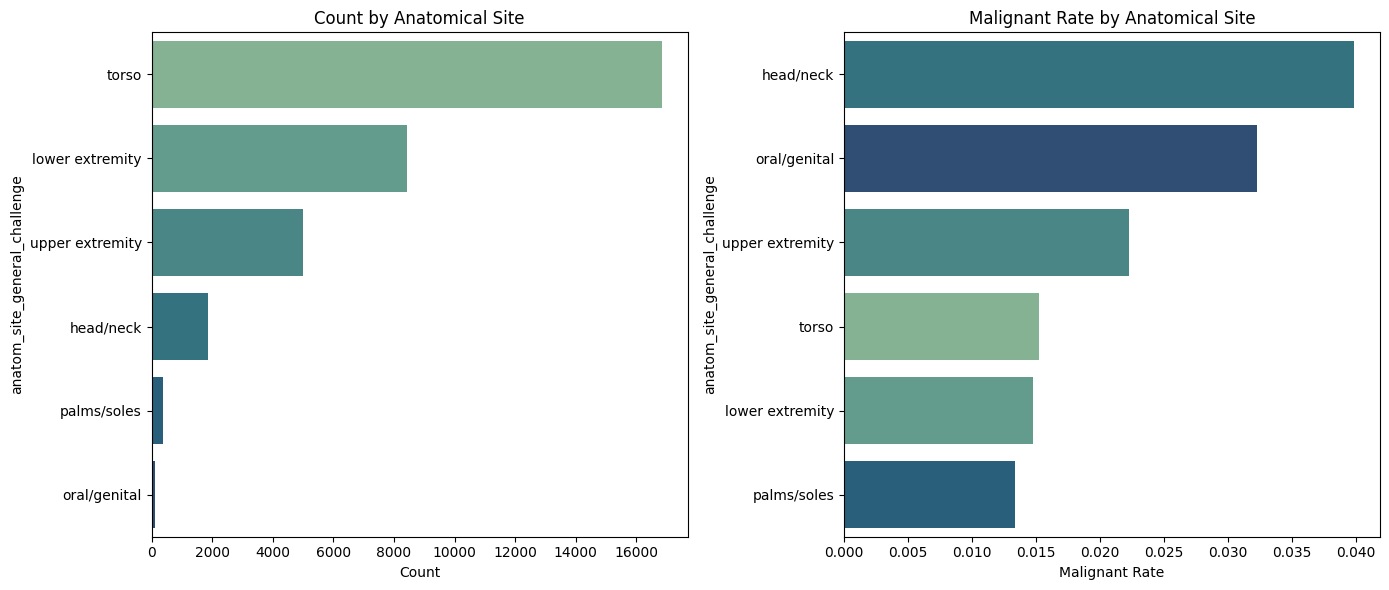

In [280]:
sites = train_df['anatom_site_general_challenge'].value_counts().index
palette_colors = sns.color_palette('crest', len(sites))
color_map = dict(zip(sites, palette_colors))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

site_counts = train_df['anatom_site_general_challenge'].value_counts()
sns.barplot(x=site_counts.values, y=site_counts.index, hue=site_counts.index, palette=color_map, legend=False, ax=axes[0])
axes[0].set_title('Count by Anatomical Site')
axes[0].set_xlabel('Count')

site_rates = train_df.groupby('anatom_site_general_challenge')['target'].mean().sort_values(ascending=False)
sns.barplot(x=site_rates.values, y=site_rates.index, hue=site_rates.index, palette=color_map, legend=False, ax=axes[1])
axes[1].set_title('Malignant Rate by Anatomical Site')
axes[1].set_xlabel('Malignant Rate')

plt.tight_layout()
plt.show()

#### Conclusion
`head/neck` shows the highest malignant rate, but also has a relatively small sample size so this estimate should be interpreted with some caution. In contrast, `torso` has a high sample count and a moderate malignant rate.

### Malignant rate by sex
---
We next examine whether sex shows any association with malignancy. The pie chart on the left shows the overall distribution of male and female patients in the dataset while the bar chart on the right shows the malignant rate for each group.

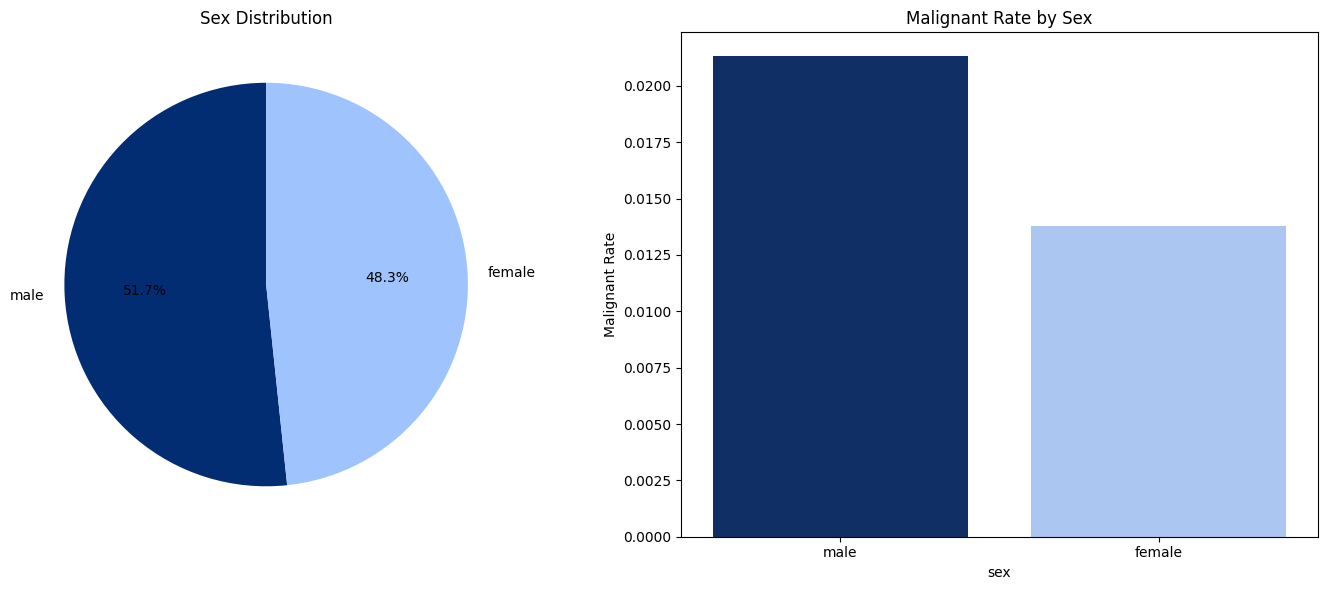

In [281]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sex_counts = train_df['sex'].value_counts()
axes[0].pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=90, colors=['#022d73', '#9fc3fc'])
axes[0].set_title('Sex Distribution')

sns.barplot(data=train_df, x='sex', y='target', hue='sex', ax=axes[1], palette=["#022d73", '#9fc3fc'], errorbar=None, legend=False)
axes[1].set_title('Malignant Rate by Sex')
axes[1].set_ylabel('Malignant Rate')

plt.tight_layout()
plt.show()

#### Conclusion
The dataset is fairly balanced between male and female patients. However, the malignant rate is higher for male patients, suggesting sex may carry some predictive signal, but it does not establish causation.

### Age distribution by target
---
We compare the age distributions of benign and malignant cases to check whether malignancy is more common in a particular age range. Since the two classes differ greatly in size, the distributions are normalized independently (`common_norm=False`) so their shapes can be compared directly regardless of the underlying imbalance.

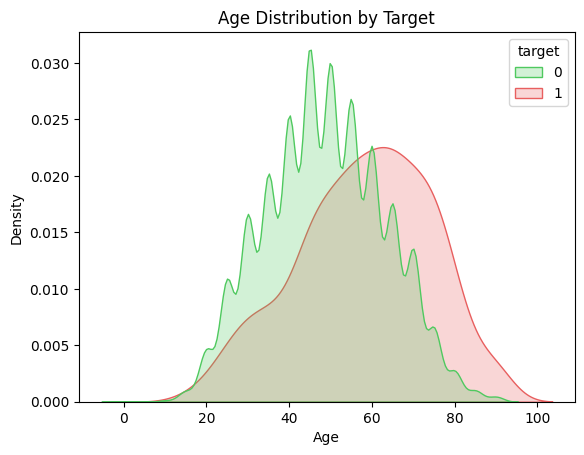

In [282]:
sns.kdeplot(data=train_df, x='age_approx', hue='target', fill=True, common_norm=False, palette=["#4FC95F", "#E85F5F"])
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.show()

### Malignant rate by age
---
To examine this relationship more precisely we calculate the exact malignant rate for each recorded age. This shows whether malignant rate increases steadily with age or fluctuates unexpectedly at certain ages.

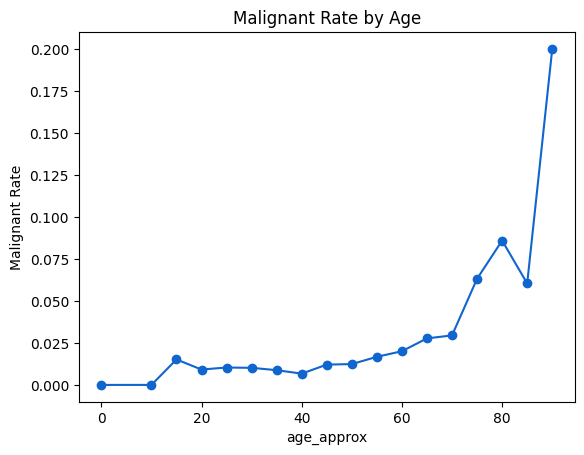

In [283]:
age_rate = train_df.groupby('age_approx')['target'].mean()

age_rate.plot(marker='o', color="#1065CE")

plt.title('Malignant Rate by Age')
plt.ylabel('Malignant Rate')
plt.show()

#### Conclusion
The malignant rate generally increases with age.

### Checking image resolution
---
As the model will require a fixed input size, we sample a subset of images to check whether their resolutions are consistent or vary significantly across the dataset.

In [284]:
sizes = [Image.open(os.path.join(TRAIN_IMG_DIR, f'{name}.jpg')).size for name in train_df['image_name'].sample(200)]
print(pd.Series(sizes).value_counts())

(6000, 4000)    97
(1872, 1053)    45
(640, 480)      20
(5184, 3456)    19
(3264, 2448)     8
(4288, 2848)     4
(2592, 1936)     4
(3888, 2592)     2
(1753, 1753)     1
Name: count, dtype: int64


#### Conclusion
Image resolutions vary considerably across the dataset, ranging from as small as 640×480 up to 6000×4000. This confirms that all images will need to be resized to a uniform input size during preprocessing regardless of the specific model architecture used.

### Visualizing resolution variance
---
To better understand the spread of image resolutions, we plot width against height for a larger sample of images. This makes it easier to see whether resolutions cluster around a few common sizes or are spread out more continuously.

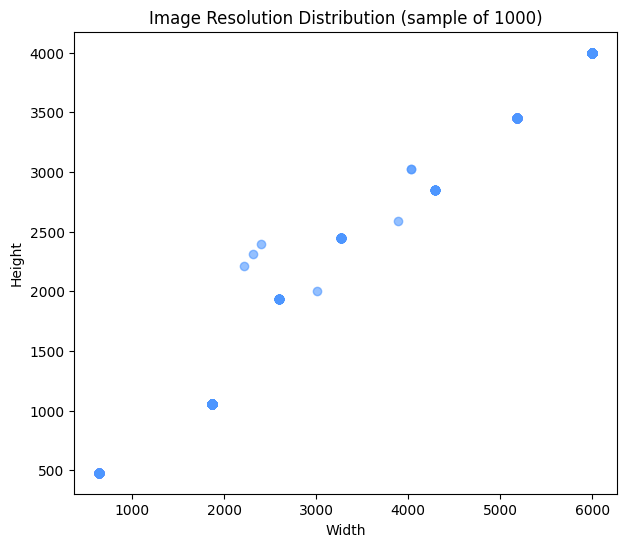

In [285]:
sizes = [Image.open(os.path.join(TRAIN_IMG_DIR, f'{name}.jpg')).size for name in train_df['image_name'].sample(1000)]

widths, heights = zip(*sizes)

plt.figure(figsize=(7, 6))
plt.scatter(widths, heights, alpha=0.6, color='#4D96FF')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Image Resolution Distribution (sample of 1000)')
plt.show()

### Age distribution and skewness
---
We examine the overall shape of the `age_approx` distribution to check whether it is symmetric or skewed.

Skewness of age_approx: 0.081


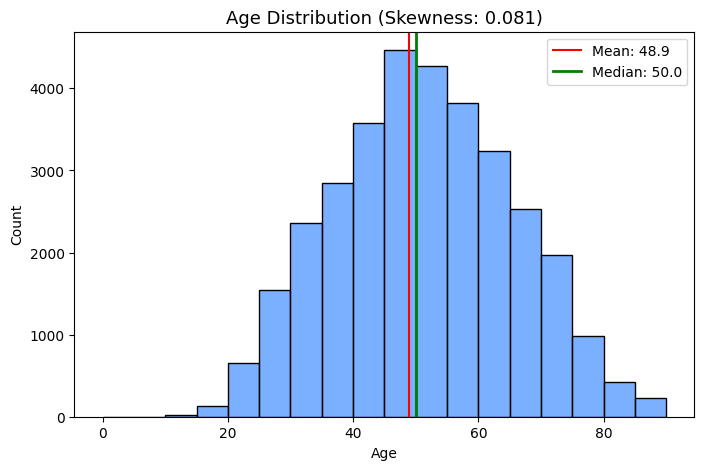

In [286]:
# Calculating the skewness to check whether age distribution is symmetric or skewed
age_skew = skew(train_df['age_approx'].dropna())
print(f"Skewness of age_approx: {age_skew:.3f}")

age_values = sorted(train_df['age_approx'].dropna().unique())

plt.figure(figsize=(8, 5))
sns.histplot(train_df['age_approx'].dropna(), color='#4D96FF', bins=age_values)
plt.axvline(train_df['age_approx'].mean(), color='red', linestyle='-', linewidth=1.5, label=f'Mean: {train_df["age_approx"].mean():.1f}')
plt.axvline(train_df['age_approx'].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {train_df["age_approx"].median():.1f}')
plt.title(f'Age Distribution (Skewness: {age_skew:.3f})', fontsize=13)
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

#### Conclusion
With a skewness of 0.081, the age distribution is effectively symmetric. No transformation is needed for this feature.

### Comparing train and test distributions
---
The model will be evaluated on the test set so it is important to check whether the distribution of key features is similar between train and test. A significant mismatch could indicate distribution shift, which may affect how well the model generalizes.

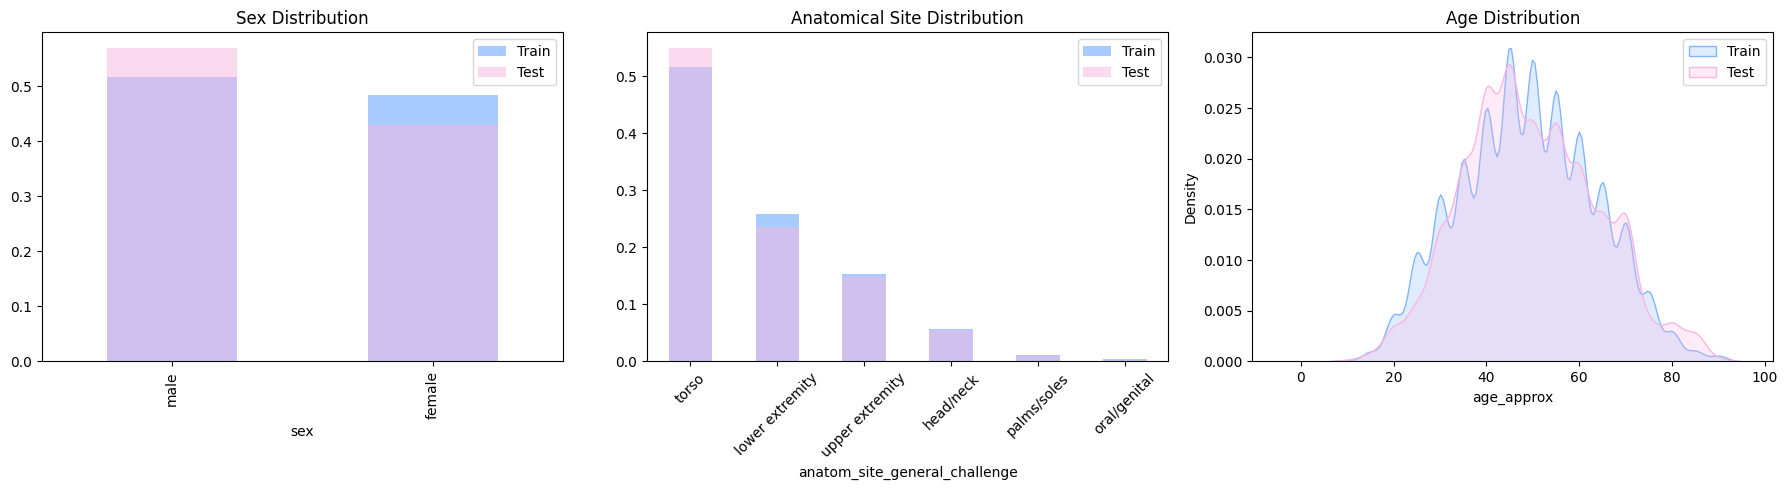

In [287]:
# Plotting train vs test distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sex distribution
train_df['sex'].value_counts(normalize=True).plot(kind='bar', ax=axes[0], color="#82B5FC", alpha=0.7, label='Train')
test_df['sex'].value_counts(normalize=True).plot(kind='bar', ax=axes[0], color="#F8B6E2", alpha=0.5, label='Test')
axes[0].set_title('Sex Distribution')
axes[0].legend()

# Anatomical site distribution
train_df['anatom_site_general_challenge'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color='#82B5FC', alpha=0.7, label='Train')
test_df['anatom_site_general_challenge'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color='#F8B6E2', alpha=0.5, label='Test')
axes[1].set_title('Anatomical Site Distribution')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# Age distribution
sns.kdeplot(train_df['age_approx'].dropna(), ax=axes[2], color='#82B5FC', label='Train', fill=True)
sns.kdeplot(test_df['age_approx'].dropna(), ax=axes[2], color='#F8B6E2', label='Test', fill=True)
axes[2].set_title('Age Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

### Example images
---
Below are sample images from each class illustrating the visual difference between benign and malignant lesions.

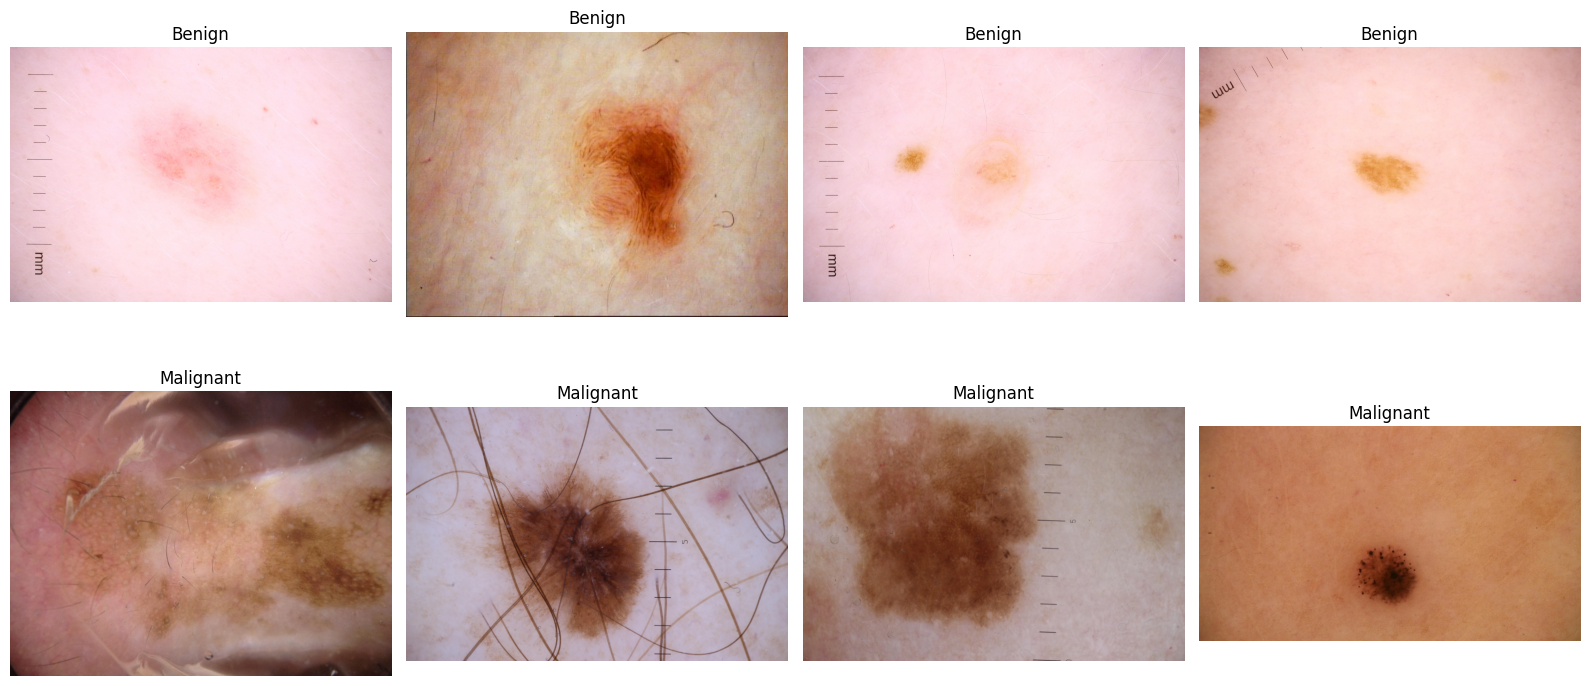

In [288]:
# Displaying 4 random benign and 4 random malignant sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

benign_samples = train_df[train_df['target']==0].sample(4, random_state=42)['image_name']
malignant_samples = train_df[train_df['target']==1].sample(4, random_state=42)['image_name']

# Benign examples
for i, img_name in enumerate(benign_samples):
    img = Image.open(os.path.join(TRAIN_IMG_DIR, f'{img_name}.jpg'))
    axes[0,i].imshow(img)
    axes[0,i].set_title('Benign')
    axes[0,i].axis('off')

# Malignant examples
for i, img_name in enumerate(malignant_samples):
    img = Image.open(os.path.join(TRAIN_IMG_DIR, f'{img_name}.jpg'))
    axes[1,i].imshow(img)
    axes[1,i].set_title('Malignant')
    axes[1,i].axis('off')

plt.tight_layout()
plt.show()